In [2]:
import pandas as pd

fish=pd.read_csv('http://bit.ly/fish_csv_data')
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [3]:
print(pd.unique(fish['Species']))
fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_input.head()

['Bream' 'Roach' 'Whitefish' 'Parkki' 'Perch' 'Pike' 'Smelt']


,Weight,Length,Diagonal,Height,Width
0,242.0,25.4,30.0,11.5200,4.0200
1,290.0,26.3,31.2,12.4800,4.3056
2,340.0,26.5,31.1,12.3778,4.6961
3,363.0,29.0,33.5,12.7300,4.4555
4,430.0,29.0,34.0,12.4440,5.1340


In [4]:
fish_target=fish['Species']

from sklearn.model_selection import train_test_split
train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)

In [5]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

In [6]:
from sklearn.neighbors import KNeighborsClassifier
kn=KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled,train_target)
print(kn.score(train_scaled,train_target))
print(kn.score(test_scaled, test_target))

0.8907563025210085
0.85


In [7]:
print(kn.classes_)
print(kn.predict(test_scaled[:5]))

import numpy as np
proba=kn.predict_proba(test_scaled[:5])
print(np.round(proba,decimals=4))

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
['Perch' 'Smelt' 'Pike' 'Perch' 'Perch']
[[0.     0.     1.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     1.     0.    ]
 [0.     0.     0.     1.     0.     0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]]


In [8]:
char_arr=np.array(['A','B','C','D','E'])
print(char_arr[[True,False,True,False,False]])

['A' 'C']


In [9]:
bream_smelt_indexes=(train_target=='Bream')|(train_target=='Smelt')
train_bream_smelt=train_scaled[bream_smelt_indexes]
target_bream_smelt=train_target[bream_smelt_indexes]

26      True
137    False
146     True
90     False
66     False
       ...  
71     False
106    False
14      True
92     False
102    False
Name: Species, Length: 119, dtype: bool


In [10]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(train_bream_smelt,target_bream_smelt)
print(lr.predict(train_bream_smelt[:5]))

['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']


In [11]:
print(lr.predict_proba(train_bream_smelt[:5]))

[[0.99760007 0.00239993]
 [0.02737325 0.97262675]
 [0.99486386 0.00513614]
 [0.98585047 0.01414953]
 [0.99767419 0.00232581]]


In [12]:
print(lr.classes_)

['Bream' 'Smelt']


In [13]:
lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.9327731092436975
0.925


In [14]:
print(lr.predict(test_scaled[:5]))

['Perch' 'Smelt' 'Pike' 'Roach' 'Perch']


In [15]:
proba=lr.predict_proba(test_scaled[:5])
print(np.round(proba,decimals=3))

[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


In [16]:
print(lr.coef_.shape,lr.intercept_.shape)

(7, 5) (7,)


In [17]:
import pandas as pd
fish=pd.read_csv('http://bit.ly/fish_csv_data')

In [18]:
fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_target=fish['Species']

In [19]:
from sklearn.model_selection import train_test_split
train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)

In [20]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

In [21]:
from sklearn.linear_model import SGDClassifier
sc=SGDClassifier(loss='log_loss', max_iter=10, random_state=42)
sc.fit(train_scaled,train_target)
print(sc.score(train_scaled,train_target))
print(sc.score(test_scaled,test_target))

0.773109243697479
0.775


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [22]:
sc.partial_fit(train_scaled,train_target)
print(sc.score(train_scaled,train_target))
print(sc.score(test_scaled,test_target))

0.7983193277310925
0.775


In [23]:
import numpy as np
sc=SGDClassifier(loss='log_loss', random_state=42)
train_score=[]
test_score=[]
classes=np.unique(train_target)

In [24]:
for _ in range(0,300):
    sc.partial_fit(train_scaled,train_target,classes=classes)
    train_score.append(sc.score(train_scaled,train_target))
    test_score.append(sc.score(test_scaled,test_target))

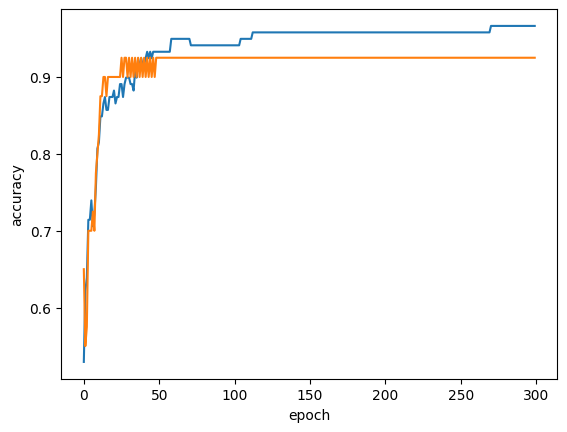

In [25]:
import matplotlib.pyplot as plt
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

In [26]:
sc=SGDClassifier(loss='log_loss', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.957983193277311
0.925


In [38]:
# 1번 과제
'''
과제 설명: 로지스틱 회귀 모델을 사용해 새로운 데이터셋에 대한 예측 결과 출력

과제 순서:
fish=pd.read_csv('http://bit.ly/fish_csv_data')
1. 위의 코드를 사용해 데이터셋을 가져오기
2, 가져온 데이터셋을 테스트 세트와 훈련 세트로 분리 (당연히 먼저 입력과 타깃부터 분리해야겠죠?)
3. 표준 정규화
4. 로지스틱 회귀 모델 훈련
5. 로지스틱 회귀 모델로 새로운 데이터셋 예측값 출력
6. 각 예측 결과에 대한 7종의 물고기 별 확률 출력
'''
# 새로운 데이터 셋
'''
test_data = np.array([
    [350.0, 29.0, 33.5, 10.50, 4.60],
    [18.5, 12.5, 14.0, 2.30, 1.35],
    [820.0, 41.5, 45.0, 7.80, 5.10],
    [160.0, 21.0, 23.5, 6.20, 3.60],
    [550.0, 26.5, 31.0, 13.80, 6.10]
])
'''
# AI의 도움을 받으시는것도 좋습니다 그러나 코드의 구성과 결과에 대해서는 정확히 알고 계시는걸 추천합니다

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

fish = pd.read_csv('http://bit.ly/fish_csv_data')

fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']]
fish_target = fish['Species']
train_input, test_input, train_target, test_target = train_test_split(fish_input, fish_target, random_state=42)

ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_scaled, train_target)

test_data = np.array([
    [350.0, 29.0, 33.5, 10.50, 4.60],
    [18.5, 12.5, 14.0, 2.30, 1.35],
    [820.0, 41.5, 45.0, 7.80, 5.10],
    [160.0, 21.0, 23.5, 6.20, 3.60],
    [550.0, 26.5, 31.0, 13.80, 6.10]
])
test_data_scaled = ss.transform(test_data)

predictions = lr.predict(test_data_scaled)
print("예측 결과:", predictions)

proba = lr.predict_proba(test_data_scaled)
print("\n예측확률")
print(lr.classes_)
print(np.round(proba, decimals=3))

예측 결과: ['Bream' 'Smelt' 'Pike' 'Perch' 'Whitefish']

예측확률
['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
[[0.451 0.049 0.008 0.006 0.384 0.    0.102]
 [0.    0.002 0.048 0.    0.009 0.941 0.   ]
 [0.    0.    0.287 0.713 0.    0.    0.   ]
 [0.    0.013 0.512 0.001 0.461 0.002 0.011]
 [0.368 0.094 0.    0.    0.009 0.    0.528]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


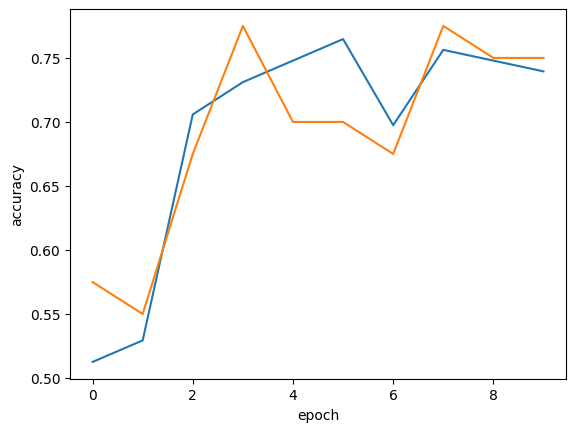

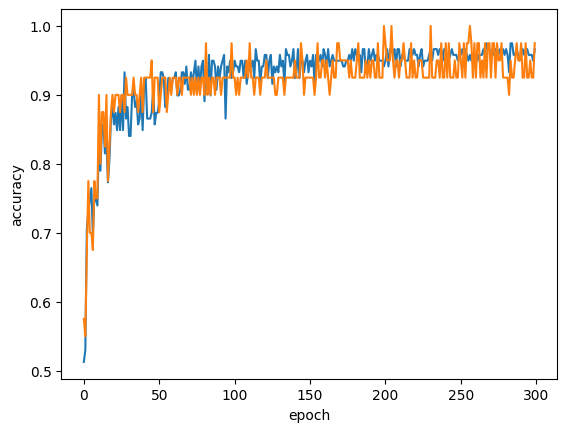

0.957983193277311
0.925


In [50]:
# 2번 과제
'''
과제 설명: SGD classifier 모델을 훈련시키고 최적의 에포크 값을 찾기

과제 순서:
fish=pd.read_csv('http://bit.ly/fish_csv_data')
1. 위의 코드를 사용해 데이터셋을 가져오기
2. SGDclassifier 모델 훈련 (loss 파라미터는 hinge로 설정, 에포크수는 10으로 설정)
3. SGDclassifier 모델 훈련 (loss 파라미터는 hinge로 설정, 에포크수는 300으로 설정)
4. 매 에포크마다 훈련 점수와 테스트 점수 기록
5. 에포크를 x축 정확도를 y축으로 하는 matplotlib 그래프 그리기
6. 눈으로 보고 적절한 에포크 수 찾기
7. 해당 에포크 수로 모델 훈련하고 점수 출력해 2번 과정의 에포크 10인 모델과 정확도 비교
'''
# AI의 도움을 받으시는것도 좋습니다 그러나 코드의 구성과 결과에 대해서는 정확히 알고 계시는걸 추천합니다
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
import numpy as np
import matplotlib.pyplot as plt

fish=pd.read_csv('http://bit.ly/fish_csv_data')
fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_target=fish['Species']
train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

sclow=SGDClassifier(loss='hinge', max_iter=10, random_state=42)
train_score_L=[]
test_score_L=[]
classes=np.unique(train_target)
for _ in range(0,10):
    sclow.partial_fit(train_scaled,train_target,classes=classes)
    train_score_L.append(sclow.score(train_scaled,train_target))
    test_score_L.append(sclow.score(test_scaled,test_target))

schigh=SGDClassifier(loss='hinge', max_iter=300, random_state=42)
train_score_H=[]
test_score_H=[]
for _ in range(0,300):
    schigh.partial_fit(train_scaled,train_target,classes=classes)
    train_score_H.append(schigh.score(train_scaled,train_target))
    test_score_H.append(schigh.score(test_scaled,test_target))

plt.plot(train_score_L)
plt.plot(test_score_L)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

plt.plot(train_score_H)
plt.plot(test_score_H)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

scnew=SGDClassifier(loss='hinge', max_iter=80, random_state=42)
scnew.fit(train_scaled,train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

# dpvhzkrk 80인 모델이 10인 모델에 비해서 훈련과 테스트 세트 모두 정확도가 높다.